In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
# Model Logic :

class KNNClassifier:
    def __init__(self,k=3):
        self.k = k

    def fit(self,x,y):
        self.x_train = x
        self.y_train = y

    def distance(self,x1,x2):
        return np.sqrt(np.sum((x2-x1)**2))
    
    def __predict_one(self,x):
        
        distances = [self.distance(x,x_train) for x_train in self.x_train]
        
        # Sort & Get the index :
        knn_index = np.argsort(distances)[:self.k]

        # K Nearest Neighbors
        k_neighbor = [self.y_train[i] for i in knn_index]

        # Majority Classes :

        majority_class = np.argmax(np.bincount(k_neighbor))

        return majority_class

    def predict(self,x):
        y_pred = [self.__predict_one(e) for e in x]
        return np.array(y_pred)

In [3]:
# Data :

X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6],
    [3, 5]
])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[0 1 0]


<Axes: xlabel='x1', ylabel='x2'>

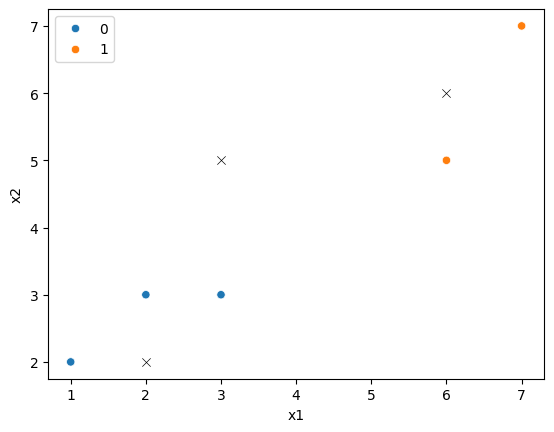

In [4]:
# Visualize :

df = pd.DataFrame(X_train, columns=["x1","x2"])
df["label"] = y_train

sns.scatterplot(
    data=df,
    x="x1",
    y="x2",
    hue="label"
)

df_test = pd.DataFrame(X_test, columns=["x1","x2"])

sns.scatterplot(
    data=df_test,
    x="x1",
    y="x2",
    color="black",
    marker="x"
)